# 05 — Dataset สำหรับฝึก: features และ CMF targets

อ่าน `dataset/processed/train.parquet` ที่สร้างด้วย `python -m src.features` และสเปกจาก `source_code/models/dataset_spec_v1.json`
- **กฎของ feature:** ต้องมาจาก Open-Meteo หรือคำนวณจากเวลา/ตำแหน่งเท่านั้น ห้ามใช้คอลัมน์ของ NASA POWER เป็น feature (ไม่มีตอนใช้งานจริง และเป็น target leakage)
- **Targets:** `cmf_uvi`, `cmf_a`, `cmf_b` = NASA POWER / ตัวหารฟ้าใสแบบไม่มีฝุ่น (เฉลี่ยทั้งชั่วโมง + ozone climatology) ตัดแถวที่ `uvi_clear < 0.5`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


In [2]:
import json

from src.features import DIAGNOSTIC, FEATURES, TARGETS

df = pd.read_parquet(ROOT / "dataset" / "processed" / "train.parquet")
spec = json.loads((ROOT / "source_code" / "models" / "dataset_spec_v1.json").read_text(encoding="utf-8"))
mid_local = (df["time_utc"] - pd.Timedelta(minutes=30)).dt.tz_convert("Asia/Bangkok")
df["hour_local"] = mid_local.dt.hour + mid_local.dt.minute / 60
df["month"] = mid_local.dt.month
print(f"{len(df)} rows, {len(FEATURES)} features, targets {TARGETS}")
print("time range:", spec["time_range_utc"])
pd.DataFrame(spec["target_stats"]).T

11173 rows, 23 features, targets ['cmf_uvi', 'cmf_a', 'cmf_b']
time range: ['2023-01-01 02:00:00+00:00', '2025-12-31 10:00:00+00:00']


,p01,p50,p99,mean,share_gt_1,share_lt_0.05
cmf_uvi,0.2496,0.6274,0.8779,0.6146,0.0000,0.0
cmf_a,0.3132,0.7425,0.9611,0.7244,0.0000,0.0
cmf_b,0.3292,0.7540,0.9995,0.7375,0.0096,0.0


## 1. การกระจายของ CMF ทั้งสามตัว

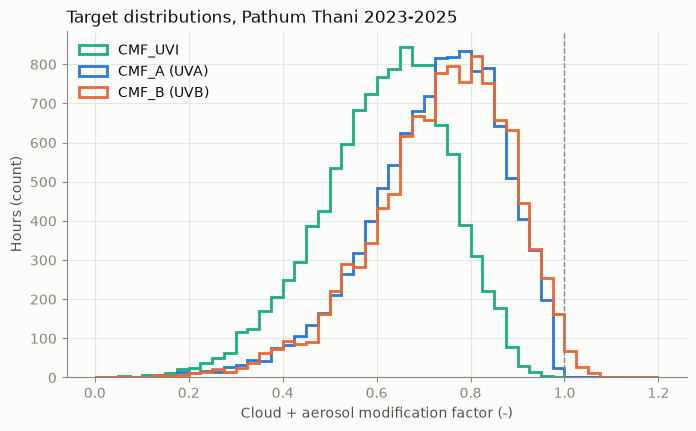

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 1.2, 49)
for t, color, name in [("cmf_uvi", C_THIRD, "CMF_UVI"), ("cmf_a", C_OM, "CMF_A (UVA)"), ("cmf_b", C_NASA, "CMF_B (UVB)")]:
    ax.hist(df[t], bins=bins, histtype="step", lw=2, color=color, label=name)
ax.axvline(1, color=MUTED, lw=1, ls="--")
ax.set_xlabel("Cloud + aerosol modification factor (-)")
ax.set_ylabel("Hours (count)")
ax.set_title("Target distributions, Pathum Thani 2023-2025", loc="left")
ax.legend(loc="upper left")
save(fig, "ds_cmf_hist.png")

## 2. CMF ตามเดือน และ ตามชั่วโมง

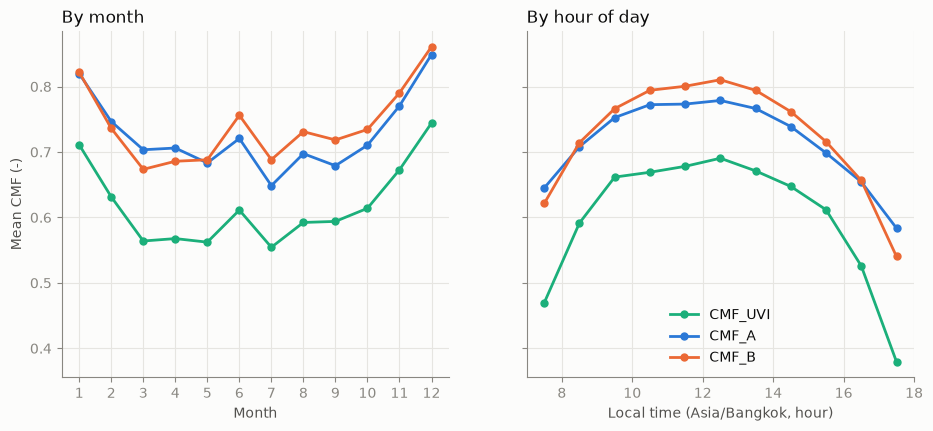

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for t, color, name in [("cmf_uvi", C_THIRD, "CMF_UVI"), ("cmf_a", C_OM, "CMF_A"), ("cmf_b", C_NASA, "CMF_B")]:
    m = df.groupby("month")[t].mean()
    h = df.groupby("hour_local")[t].mean()
    axes[0].plot(m.index, m, color=color, marker="o", ms=5, label=name)
    axes[1].plot(h.index, h, color=color, marker="o", ms=5, label=name)
axes[0].set_xticks(range(1, 13)); axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean CMF (-)")
axes[0].set_title("By month", loc="left")
axes[1].set_xlabel("Local time (Asia/Bangkok, hour)")
axes[1].set_title("By hour of day", loc="left")
axes[1].legend(loc="lower center")
save(fig, "ds_cmf_month_hour.png")

## 3. Correlation ระหว่าง feature กับ target
เทียบกับคอลัมน์วินิจฉัยของ NASA POWER (ซึ่ง**ไม่ได้**ใช้เป็น feature) เพื่อแสดงว่าทำไมต้องตัดออก: clear-sky index ของ NASA มาจากผลิตภัณฑ์เดียวกับ target

,cmf_uvi,cmf_a,cmf_b
cos_sza,0.394,0.242,0.361
hour_sin,0.081,0.093,0.083
hour_cos,-0.522,-0.369,-0.470
month_sin,-0.201,-0.114,-0.200
month_cos,0.278,0.329,0.194
uv_index,0.544,0.462,0.497
uv_index_clear_sky,0.410,0.259,0.372
cloud_cover,-0.309,-0.426,-0.285
cloud_cover_low,-0.158,-0.258,-0.155
cloud_cover_mid,-0.279,-0.400,-0.281


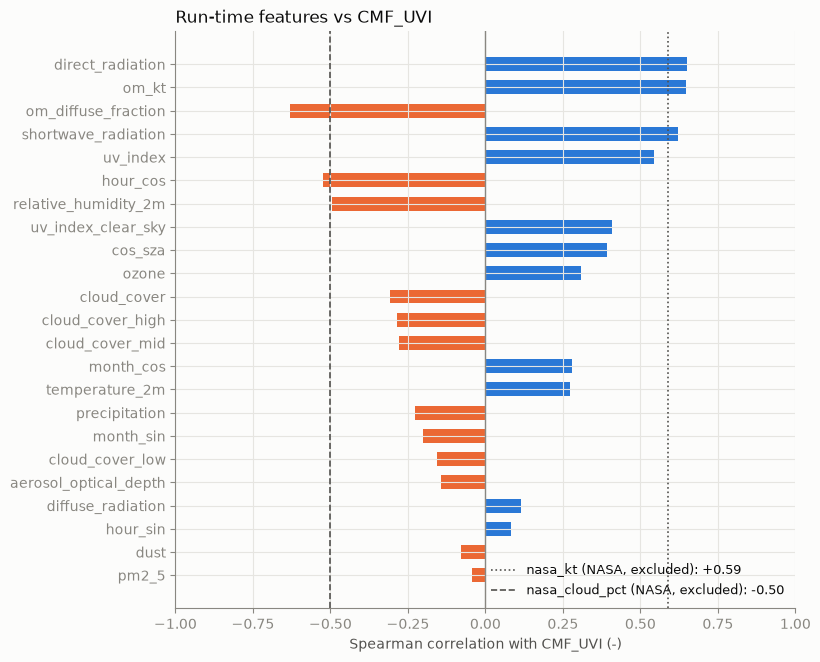

In [5]:
corr = df[FEATURES + TARGETS].corr(method="spearman").loc[FEATURES, TARGETS]
diag = df.assign(nasa_kt=df["nasa_sw_all_wm2"] / df["nasa_sw_clear_wm2"])
diag_corr = diag[["nasa_kt", "nasa_cloud_pct"] + TARGETS].corr(method="spearman").loc[["nasa_kt", "nasa_cloud_pct"], TARGETS]

order = corr["cmf_uvi"].abs().sort_values().index
fig, ax = plt.subplots(figsize=(8, 7.5))
y = np.arange(len(order))
ax.barh(y, corr.loc[order, "cmf_uvi"], color=[C_OM if v >= 0 else C_NASA for v in corr.loc[order, "cmf_uvi"]], height=0.6)
ax.set_yticks(y, order)
ax.axvline(0, color=MUTED, lw=1)
for (label, val), ls in zip(diag_corr["cmf_uvi"].items(), [":", "--"]):
    ax.axvline(val, color=INK2, lw=1.2, ls=ls, label=f"{label} (NASA, excluded): {val:+.2f}")
ax.set_xlim(-1, 1)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Spearman correlation with CMF_UVI (-)")
ax.set_title("Run-time features vs CMF_UVI", loc="left")
save(fig, "ds_feature_corr.png")
pd.concat([corr, diag_corr]).round(3)

## สรุป

1. **ขนาด dataset:** 11,173 ชั่วโมง (ปี 2023–2025) มี 23 features และ 3 targets ไม่มีค่า NaN จาก 13,280 ชั่วโมงกลางวัน ตัดออก 2,107 ชั่วโมงเพราะ `uvi_clear < 0.5` (ช่วงเช้าตรู่และเย็น)
2. **ช่วงค่าของ CMF:** อยู่ในช่วง 0.25–0.96 (p01–p99) มีเพียง `cmf_b` ราว 1% ที่เกิน 1 ส่วนค่าต่ำกว่า 0.05 ไม่มีเลย แปลว่าแทบไม่ต้อง clip เรื่องนี้จะตัดสินในวัน 6 ระดับของ CMF_UVI (ค่ามัธยฐาน 0.63) ต่ำกว่า CMF_A/B (~0.75) ตรงกับผลวัน 3–4 ว่า Madronich ให้ค่าสูงกว่า SPECTRL2 เมื่อเทียบกับ NASA
3. **CMF ยังขึ้นกับเรขาคณิตของดวงอาทิตย์:** ตอนดวงอาทิตย์ต่ำ CMF_UVI ลดเหลือราว 0.4 (Spearman กับ `cos_sza` = +0.39, กับ `hour_cos` = −0.52) CMF จึงไม่ได้แทนแค่ผลของเมฆและฝุ่น แต่รวมความคลาดของโมเดลฟ้าใสตามมุมเซนิทด้วย feature `cos_sza` และ hour จึงจำเป็น และเป็นเรื่องที่ต้องระบุในรายงาน
4. **Feature ที่ใช้ตอนใช้งานได้ให้ข้อมูลใกล้เคียงกับของ NASA:** feature ที่สัมพันธ์กับ CMF_UVI มากที่สุดคือ `direct_radiation` (+0.65), `om_kt` (+0.65), `om_diffuse_fraction` (−0.63) และ `shortwave_radiation` (+0.62) ซึ่งใกล้กับหรือมากกว่า clear-sky index ของ NASA (+0.59) ที่ตัดออกไป แต่สำหรับ CMF_A ตัวของ NASA สัมพันธ์สูงกว่า (+0.78 เทียบกับ `om_kt` +0.69) ซึ่งเป็นสัญญาณของ leakage ที่ตัดออกไปแล้ว
5. **ข้อสังเกต:** AOD และ PM2.5 สัมพันธ์กับ CMF แบบ Spearman รวมไม่มาก (−0.15/−0.04) เพราะผลของเมฆกลบไว้ แต่ในชั่วโมงฟ้าเปิดวัน 3–4 เห็นผลของฝุ่นชัดเจน จึงคงไว้เป็น feature
